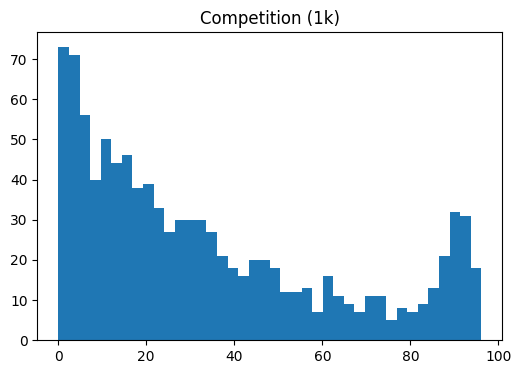

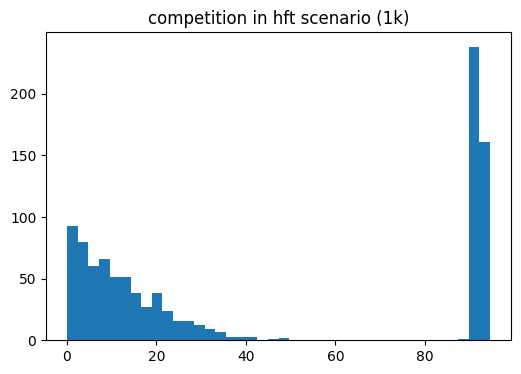

Best PNL in nice scenario: 206597.80662010427
Best allocation in nice scenario: (18, 57, 25)
Best PNL in adversarial scenario: 221972.93162346835
Best allocation in adversarial scenario: (19, 58, 23)
Refined Best PnL: 206597.80662010427
Refined allocation: (18, 57, 25)
Refined Best PnL for hft scenario: 221972.93162346835
Refined allocation for hft scenario: (19, 58, 23)


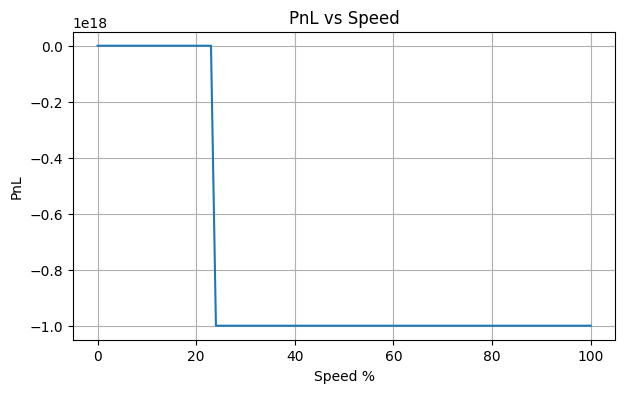

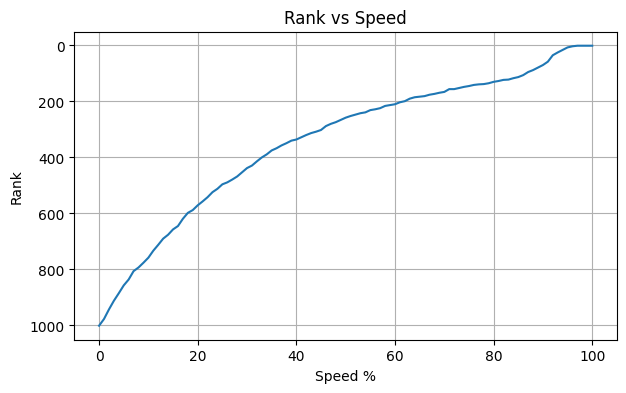

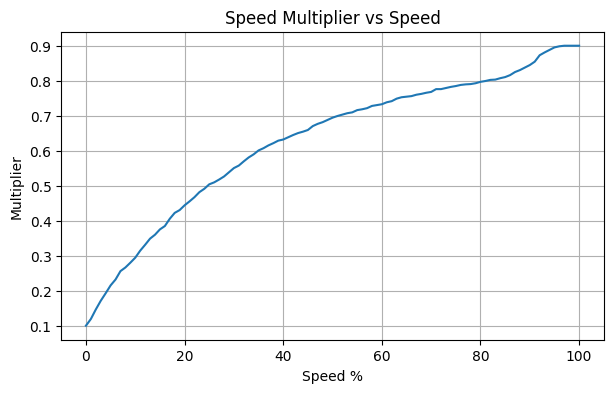

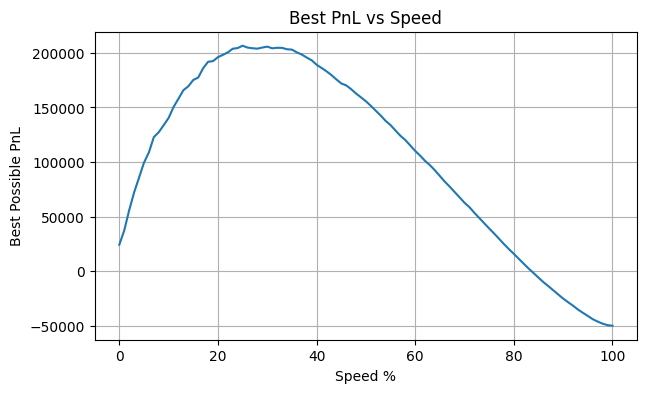

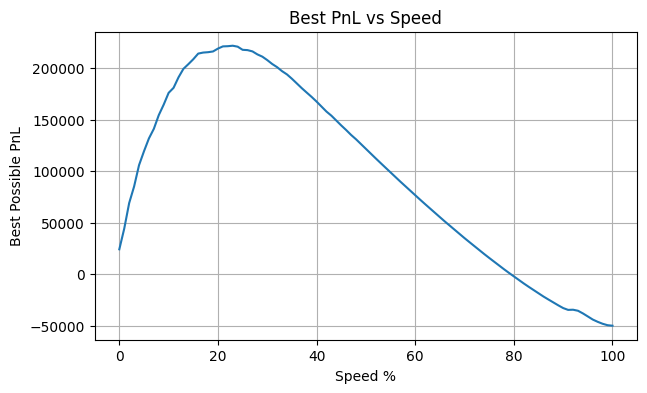

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ========================
# CONFIG
# ========================
BUDGET = 50000
STEP = 1  # coarse search step

# ========================
# PILLAR FUNCTIONS
# ========================
def research(x):
    return 200_000 * np.log(1 + x) / np.log(101)

def scale(x):
    return 7 * x / 100

# ========================
# COMPETITION GENERATION with simulated competition (many low and mid tier speeds)
# ========================
def generate_competition(n=1000, seed=42):
    np.random.seed(seed)
    
    n_low = int(0.6 * n)
    n_mid = int(0.3 * n)
    n_top = n - n_low - n_mid
    
    low = np.random.beta(1, 5, size=n_low) * 100
    mid = np.random.beta(2, 2, size=n_mid) * 100
    top = np.random.normal(loc=90, scale=3, size=n_top)
    top = np.clip(top, 70, 100)
    
    return np.concatenate([low, mid, top])

# COMPETITON GENERATION with simulated market competition (clustered at HFT speeds)

def generate_competition_hft(n=1000, seed=42):
    np.random.seed(seed)
    
    n_top = int(0.4 * n)   # teams going for the highiest spd
    n_rest = n - n_top
    
    # rest (mostly irrelevant)
    rest = np.random.beta(1, 4, size=n_rest) * 60  # capped lower
    
    # elite cluster (tight!)
    top = np.random.normal(loc=92, scale=0.8, size=n_top)
    top = np.clip(top, 85, 100)
    
    speeds = np.concatenate([rest, top])
    return speeds

def preprocess_competition(others):
    return np.sort(others)

# ========================
# FAST RANK SPEED
# ========================
def rank_speed_fast(my_sp, sorted_others):
    idx = np.searchsorted(sorted_others, my_sp, side='right')
    rank = len(sorted_others) - idx + 1
    n = len(sorted_others) + 1
    return 0.9 - (rank - 1) * (0.8 / (n - 1))

# ========================
# PnL
# ========================
def pnl(r, s, sp, sorted_others):
    if r + s + sp > 100:
        return -1e18
    
    R = research(r)
    S = scale(s)
    V = rank_speed_fast(sp, sorted_others)
    cost = BUDGET * (r + s + sp) / 100
    
    return R * S * V - cost

# ========================
# RUN
# ========================
others = generate_competition(1000)
others_hft = generate_competition_hft(1000)

sorted_others = preprocess_competition(others)
sorted_others_hft = preprocess_competition(others_hft)

# histogram
plt.figure(figsize=(6,4))
plt.hist(others, bins=40)
plt.title("Competition (1k)")
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(others_hft, bins = 40)
plt.title("competition in hft scenario (1k)")
plt.show()

# ========================
# COARSE GRID SEARCH
# ========================
best_val = -1e18
best_alloc = None

hft_best_val = -1e18
hft_best_alloc = None

for r in range(0, 101, STEP):
    for s in range(0, 101 - r, STEP):
        for sp in range(0, 101 - r - s, STEP):
            val = pnl(r, s, sp, sorted_others)
            hft_val = pnl(r, s, sp, sorted_others_hft)

            if val > best_val:
                best_val = val
                best_alloc = (r, s, sp)

            if hft_val > hft_best_val:
                hft_best_val = hft_val
                hft_best_alloc = (r, s, sp)

print("Best PNL in nice scenario:", best_val)
print("Best allocation in nice scenario:", best_alloc)

print("Best PNL in adversarial scenario:", hft_best_val)
print("Best allocation in adversarial scenario:", hft_best_alloc)



# ========================
# LOCAL REFINEMENT
# ========================
r0, s0, sp0 = best_alloc

best_val2 = best_val
best_alloc2 = best_alloc

for r in range(max(0, r0-STEP), min(100, r0+STEP)+1):
    for s in range(max(0, s0-STEP), min(100-r, s0+STEP)+1):
        for sp in range(max(0, sp0-STEP), min(100-r-s, sp0+STEP)+1):
            val = pnl(r, s, sp, sorted_others)
            if val > best_val2:
                best_val2 = val
                best_alloc2 = (r, s, sp)

print("Refined Best PnL:", best_val2)
print("Refined allocation:", best_alloc2)

r0, s0, sp0 = hft_best_alloc

best_val2 = hft_best_val
best_alloc2 = hft_best_alloc

for r in range(max(0, r0-STEP), min(100, r0+STEP)+1):
    for s in range(max(0, s0-STEP), min(100-r, s0+STEP)+1):
        for sp in range(max(0, sp0-STEP), min(100-r-s, sp0+STEP)+1):
            val = pnl(r, s, sp, sorted_others_hft)
            if val > best_val2:
                best_val2 = val
                best_alloc2 = (r, s, sp)

print("Refined Best PnL for hft scenario:", best_val2)
print("Refined allocation for hft scenario:", best_alloc2)

# ========================
# ANALYSIS PLOTS
# ========================

sp_vals = list(range(101))

# 1. PnL vs Speed (MOST IMPORTANT)
pnl_vals = []
r_fix, s_fix, _ = best_alloc2

for sp in sp_vals:
    pnl_vals.append(pnl(r_fix, s_fix, sp, sorted_others))

plt.figure(figsize=(7,4))
plt.plot(sp_vals, pnl_vals)
plt.title("PnL vs Speed")
plt.xlabel("Speed %")
plt.ylabel("PnL")
plt.grid()
plt.show()

# 2. Rank vs Speed
ranks = []
for sp in sp_vals:
    idx = np.searchsorted(sorted_others, sp, side='right')
    rank = len(sorted_others) - idx + 1
    ranks.append(rank)

plt.figure(figsize=(7,4))
plt.plot(sp_vals, ranks)
plt.gca().invert_yaxis()
plt.title("Rank vs Speed")
plt.xlabel("Speed %")
plt.ylabel("Rank")
plt.grid()
plt.show()

# 3. Speed Multiplier curve
multipliers = [rank_speed_fast(sp, sorted_others) for sp in sp_vals]

plt.figure(figsize=(7,4))
plt.plot(sp_vals, multipliers)
plt.title("Speed Multiplier vs Speed")
plt.xlabel("Speed %")
plt.ylabel("Multiplier")
plt.grid()
plt.show()

# 4. Best PnL achievable for each Speed
best_pnl_by_sp = []

for sp in sp_vals:
    best_local = -1e18
    for r in range(0, 101, STEP):
        for s in range(0, 101 - r, STEP):
            val = pnl(r, s, sp, sorted_others)
            if val > best_local:
                best_local = val
    best_pnl_by_sp.append(best_local)

plt.figure(figsize=(7,4))
plt.plot(sp_vals, best_pnl_by_sp)
plt.title("Best PnL vs Speed")
plt.xlabel("Speed %")
plt.ylabel("Best Possible PnL")
plt.grid()
plt.show()



# 4. Best PnL achievable for each Speed
best_pnl_by_sp = []

for sp in sp_vals:
    pnl_vals.append(pnl(r_fix, s_fix, sp, sorted_others_hft))

for sp in sp_vals:
    best_local = -1e18
    for r in range(0, 101, STEP):
        for s in range(0, 101 - r, STEP):
            val = pnl(r, s, sp, sorted_others_hft)
            if val > best_local:
                best_local = val
    best_pnl_by_sp.append(best_local)

plt.figure(figsize=(7,4))
plt.plot(sp_vals, best_pnl_by_sp)
plt.title("Best PnL vs Speed")
plt.xlabel("Speed %")
plt.ylabel("Best Possible PnL")
plt.grid()
plt.show()